# QAA to Solve a QUBO Problem with `qiskit-pasqal-provider`

This notebook presents a complete workflow to solve a QUBO instance with `qiskit-pasqal-provider` on a local `qutip` backend.

Further reading:
- [QAA to solve a QUBO problem](https://pulser.readthedocs.io/en/stable/tutorials/qubo.html)


In [1]:
# pylint: disable=missing-module-docstring,missing-function-docstring,pointless-statement,redefined-outer-name,invalid-name,expression-not-assigned
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
from pulser import Register
from pulser.devices import DigitalAnalogDevice
from qiskit import QuantumCircuit

from qiskit_pasqal_provider.providers.layouts import FreeLayout
from qiskit_pasqal_provider.providers.gate import HamiltonianGate, InterpolatePoints
from qiskit_pasqal_provider.providers.provider import PasqalProvider
from qiskit_pasqal_provider.providers.sampler import SamplerV2
from qiskit_pasqal_provider.providers.target import PasqalTarget

## Introduction

In this notebook, we solve a Quadratic Unconstrained Binary Optimization (QUBO) problem with neutral-atom analog evolution.

A QUBO instance is defined by a symmetric matrix $Q$. The optimization task is to find $z \in \{0,1\}^N$ that minimizes:

$$
f(z) = z^TQz
$$

The matrix below is a compact 5-variable example. Since this problem is small, we first compute the exact classical optimum by brute force and use it as a reference.

This instance is convenient for neutral-atom encoding because:

1. off-diagonal entries are positive (compatible with positive Rydberg interactions),
2. diagonal entries are equal (global detuning is enough).


In [2]:
Q = np.array(
    [
        [-10.0, 19.7365809, 19.7365809, 5.42015853, 5.42015853],
        [19.7365809, -10.0, 20.67626392, 0.17675796, 0.85604541],
        [19.7365809, 20.67626392, -10.0, 0.85604541, 0.17675796],
        [5.42015853, 0.17675796, 0.85604541, -10.0, 0.32306662],
        [5.42015853, 0.85604541, 0.17675796, 0.32306662, -10.0],
    ]
)
Q

array([[-10.        ,  19.7365809 ,  19.7365809 ,   5.42015853,
          5.42015853],
       [ 19.7365809 , -10.        ,  20.67626392,   0.17675796,
          0.85604541],
       [ 19.7365809 ,  20.67626392, -10.        ,   0.85604541,
          0.17675796],
       [  5.42015853,   0.17675796,   0.85604541, -10.        ,
          0.32306662],
       [  5.42015853,   0.85604541,   0.17675796,   0.32306662,
        -10.        ]])

In [3]:
def bitstring_cost(bitstring: str, qubo: np.ndarray) -> float:
    z = np.array(list(bitstring), dtype=int)
    return float(z.T @ qubo @ z)


bitstrings = [np.binary_repr(i, len(Q)) for i in range(2 ** len(Q))]
ranked = sorted(((b, bitstring_cost(b, Q)) for b in bitstrings), key=lambda x: x[1])
optimal_bitstrings = [b for b, c in ranked if np.isclose(c, ranked[0][1])]
print("Top 5 classical solutions:")
for b, c in ranked[:5]:
    print(f"{b}: {c:.9f}")
print("\nOptimal bitstrings:", optimal_bitstrings)

Top 5 classical solutions:
01011: -27.288260020
00111: -27.288260020
00101: -19.646484080
01010: -19.646484080
00011: -19.353866760

Optimal bitstrings: ['01011', '00111']


## Solving the QUBO with `qiskit-pasqal-provider`

Pulser-style Ising dynamics can be programmed through `HamiltonianGate` and executed with `SamplerV2`.

The mapping idea is:

$$
\left[\frac{C_6}{R_{ij}^6}\right]_{i \neq j} \leftrightarrow Q_{\text{off-diagonal}}
$$

### 1. Pick a Device

We explicitly target `DigitalAnalogDevice`.

### 2. Create the Register

We optimize atom coordinates so that pairwise interaction strengths approximate the QUBO couplings. The resulting coordinates define the register used by the analog gate.


In [4]:
provider = PasqalProvider()
layout = FreeLayout([(0.0, 0.0)], slug="qubo-layout")
target = PasqalTarget(device=DigitalAnalogDevice, layout=layout)
backend = provider.get_backend("qutip", target=target)
sampler = SamplerV2(backend)
device = backend.target.device

print("Backend:", backend.name)
print("Device:", device.name)
print("Interaction coefficient:", device.interaction_coeff)
print("Max sequence duration (ns):", device.max_sequence_duration)

# Real QPU execution options:
# 1) Pasqal Cloud (FRESNEL QPU)
# from qiskit_pasqal_provider.utils import RemoteConfig
# remote_config = RemoteConfig(
#     username="<PASQAL_USERNAME>",
#     password="<PASQAL_PASSWORD>",
#     project_id="<PASQAL_PROJECT_ID>",
# )
# provider = PasqalProvider(remote_config=remote_config)
# backend = provider.get_backend("fresnel")
# sampler = SamplerV2(backend)
#
# 2) On-prem scheduler via QRMI
# Keep the same circuit construction and sampling flow, and submit through QRMI.
# https://github.com/qiskit-community/qrmi

Backend: QutipEmulatorBackend
Device: DigitalAnalogDevice
Interaction coefficient: 5420158.53
Max sequence duration (ns): None


In [5]:
def evaluate_mapping(
    new_coords: np.ndarray, qubo: np.ndarray, interaction_coeff: float
) -> float:
    coords = np.reshape(new_coords, (len(qubo), 2))
    mapped = squareform(interaction_coeff / pdist(coords) ** 6)
    return float(np.linalg.norm(mapped - qubo))


np.random.seed(0)
x0 = np.random.random(len(Q) * 2)
res = minimize(
    evaluate_mapping,
    x0,
    args=(Q, device.interaction_coeff),
    method="Nelder-Mead",
    tol=1e-6,
    options={"maxiter": 100000, "maxfev": None},
)
coords = np.reshape(res.x, (len(Q), 2))
coords

array([[ 2.31281516, -0.23002871],
       [-2.93655481, -6.36935057],
       [-5.62649393,  1.15594212],
       [ 8.49894067, -8.25563437],
       [ 3.34198769,  9.94592252]])

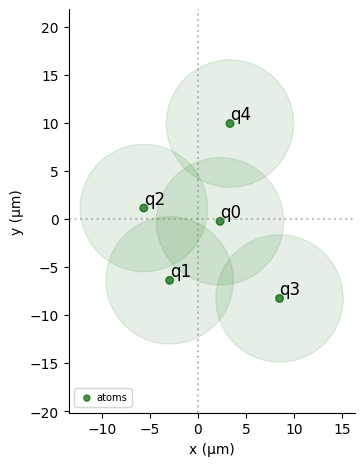

In [6]:
qubits = {f"q{i}": coord for i, coord in enumerate(coords)}
reg = Register(qubits)
reg.draw(
    blockade_radius=device.rydberg_blockade_radius(1.0),
    draw_graph=False,
    draw_half_radius=True,
)

### 3. Pick the channels

In the Pulser sequence this would be a `rydberg_global` channel declaration.
With `qiskit-pasqal-provider`, this channel selection is handled internally when building the sequence from `HamiltonianGate`.

### 4. Add the Pulses

Following the same adiabatic idea, we use a pulse schedule that:

- starts from low amplitude and negative detuning,
- ramps through an intermediate region,
- ends at low amplitude and positive detuning.

If the evolution is slow enough, sampled bitstrings concentrate near low-energy (low-cost) QUBO solutions.


In [7]:
Omega = float(np.median(Q[Q > 0]))
delta_0 = -5.0
delta_f = 5.0


def build_qubo_circuit(duration_ns: int) -> QuantumCircuit:
    times = [0.0, 0.5, 1.0]
    amplitude = InterpolatePoints(
        values=[1e-9, Omega, 1e-9],
        duration=duration_ns,
        times=times,
    )
    detuning = InterpolatePoints(
        values=[delta_0, 0.0, delta_f],
        duration=duration_ns,
        times=times,
    )
    gate = HamiltonianGate(amplitude, detuning, 0.0, coords)
    qc = QuantumCircuit(len(Q))
    qc.append(gate, qc.qubits)
    return qc

In [8]:
duration_ns = 4000
shots = 1000
qubo_qc = build_qubo_circuit(duration_ns)
result = sampler.run([qubo_qc], shots=shots).result()
counts = dict(sorted(result[0].data.counts.items(), key=lambda x: x[1], reverse=True))
list(counts.items())[:10]

[('00111', 566),
 ('01011', 321),
 ('00011', 83),
 ('01001', 14),
 ('00110', 7),
 ('10000', 3),
 ('10010', 2),
 ('00001', 2),
 ('10001', 1),
 ('10011', 1)]

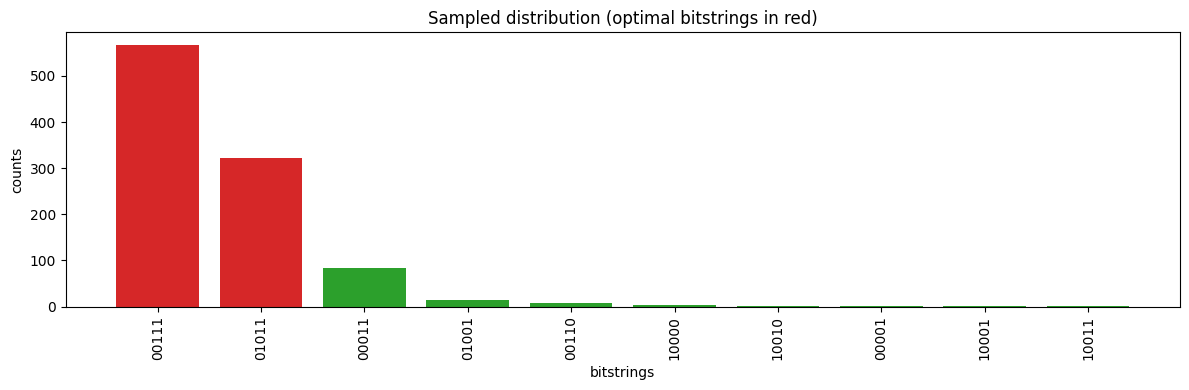

In [9]:
bar_colors = ["tab:red" if b in optimal_bitstrings else "tab:green" for b in counts]
plt.figure(figsize=(12, 4))
plt.bar(counts.keys(), counts.values(), color=bar_colors)
plt.xticks(rotation=90)
plt.xlabel("bitstrings")
plt.ylabel("counts")
plt.title("Sampled distribution (optimal bitstrings in red)")
plt.tight_layout()
plt.show()

The red bars correspond to the exact classical optima (`01011` and `00111`).

With a good adiabatic schedule, these low-cost bitstrings dominate the sampled distribution.


## How does the time evolution affect the quality of the results?

We evaluate quality through the sampled, count-weighted QUBO cost:

$$
\sum_i \frac{c_i}{\sum_j c_j} z_i^TQz_i
$$

We sweep total evolution time from 1 to 10 microseconds and track how this average cost changes.


In [10]:
def average_qubo_cost(counter: dict[str, int], qubo: np.ndarray) -> float:
    weighted = sum(counter[b] * bitstring_cost(b, qubo) for b in counter)
    return weighted / sum(counter.values())


time_grid_us = np.arange(1, 11, dtype=int)
costs = []
for t_us in time_grid_us:
    qc_t = build_qubo_circuit(int(t_us * 1000))
    counts_t = sampler.run([qc_t], shots=3000).result()[0].data.counts
    costs.append(average_qubo_cost(counts_t, Q))
costs

[-18.757088925906665,
 -21.6228470171,
 -23.412233603906667,
 -26.161913006379997,
 -25.866347384106664,
 -26.34293043648,
 -26.734600752413332,
 -26.860708759186664,
 -26.929201589659996,
 -27.075046053393333]

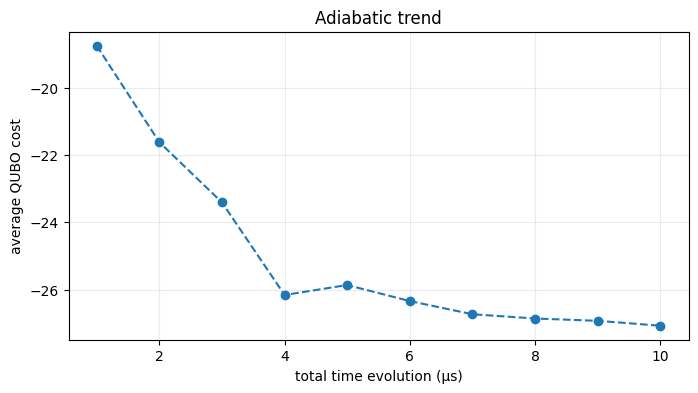

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(time_grid_us, costs, "--o")
plt.xlabel("total time evolution (µs)")
plt.ylabel("average QUBO cost")
plt.title("Adiabatic trend")
plt.grid(alpha=0.25)
plt.show()

## To go further

- The simple heuristic used here for `Omega` and detuning works for this QUBO, but other instances can require retuning.
- A practical next step is to wrap schedule parameters in an outer optimization loop minimizing the sampled average cost.
- For more general QUBOs (for example, mixed-sign or structure requiring local control), local addressability strategies may be needed.
